# Preprocessing — Optimisation du ROI Marketing
### Préparation des données pour la modélisation
---

## 0. Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print('Imports OK ✅')

Imports OK ✅


## 1. Chargement des données

In [5]:
root_dir = Path.cwd().parent
df = pd.read_csv(root_dir / 'data' / 'Dummy_Data_HSS.csv')
print(f'Shape initiale : {df.shape}')
df.head()

Shape initiale : (4572, 5)


,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


## 2. Localisation précise des valeurs manquantes

=== Valeurs manquantes par colonne ===
              Count  Percentage (%)
TV               10            0.22
Social Media      6            0.13
Sales             6            0.13
Radio             4            0.09
Influencer        0            0.00


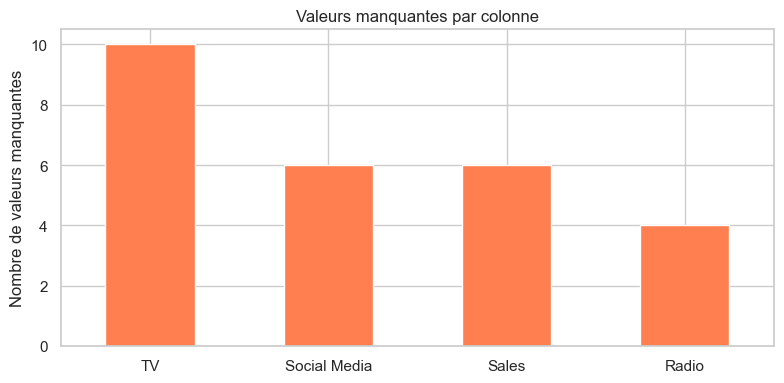

In [6]:
print('=== Valeurs manquantes par colonne ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Count': missing,
    'Percentage (%)': missing_pct
}).sort_values('Count', ascending=False)
print(missing_df)

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
missing_df[missing_df['Count'] > 0]['Count'].plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Valeurs manquantes par colonne')
ax.set_ylabel('Nombre de valeurs manquantes')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# Regarder les lignes avec des valeurs manquantes
print('=== Aperçu des lignes avec valeurs manquantes ===')
df_missing = df[df.isnull().any(axis=1)]
print(f'Nombre de lignes concernées : {len(df_missing)}')
print(f'Soit {len(df_missing)/len(df)*100:.2f}% du dataset')
print()
print(df_missing.head(10))

=== Aperçu des lignes avec valeurs manquantes ===
Nombre de lignes concernées : 26
Soit 0.57% du dataset

       TV      Radio  Social Media Influencer       Sales
13    NaN  22.351667      3.031815       Mega  276.165351
26    NaN  34.111674      4.624148       Nano  342.913372
46    NaN  34.859637      7.781417       Mega  318.969784
75    NaN   6.482293      0.866845      Macro   91.177216
99    NaN   7.635819      1.554146      Macro   56.186730
119   NaN  30.470485      6.806919      Micro  336.818690
141   NaN   9.164464      1.096681      Macro   65.259189
163   NaN  38.118424      6.676611      Micro  328.555184
182  81.0  26.425422           NaN      Macro  288.649441
183   NaN   1.287060      0.396179      Macro   56.545293


## 3. Nettoyage des données

### Stratégie :
- **Variables numériques** (TV, Radio, Social Media, Sales) → imputation par la **médiane** (robuste aux outliers)
- **Variable catégorielle** (Influencer) → imputation par le **mode** (valeur la plus fréquente)
- On garde les lignes : 132 manquants sur 4572 lignes (~3%) ne justifie pas une suppression massive


In [8]:
# Colonnes originales du dataset
original_cols = ['TV', 'Radio', 'Social Media', 'Influencer', 'Sales']
df = df[original_cols].copy()

# Vérification avant nettoyage
print('Avant nettoyage :')
print(f'  Shape : {df.shape}')
print(f'  Valeurs manquantes : {df.isnull().sum().sum()}')

Avant nettoyage :
  Shape : (4572, 5)
  Valeurs manquantes : 26


In [ ]:
# Imputation manuelle pour Sales (variable cible)
# On impute Sales séparément car c'est la cible — elle ne doit pas passer dans le pipeline
#sales_median = df['Sales'].median()
#df['Sales'] = df['Sales'].fillna(sales_median)
#print(f'Sales imputée avec la médiane : {sales_median:.2f} M€')

# Vérification
#print(f'Valeurs manquantes restantes dans Sales : {df["Sales"].isnull().sum()}')

Sales imputée avec la médiane : 189.23 M€
Valeurs manquantes restantes dans Sales : 0


## 4. Séparation Features / Target + Train / Test Split

In [23]:
# Features et target
FEATURES = ['TV', 'Radio', 'Social Media', 'Influencer']
TARGET = 'Sales'

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'Features : {FEATURES}')
print(f'Target   : {TARGET}')

X shape : (4572, 4)
y shape : (4572,)
Features : ['TV', 'Radio', 'Social Media', 'Influencer']
Target   : Sales


In [24]:
# Train / Test split — 80% train, 20% test
# random_state=42 pour la reproductibilité
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Train : {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test  : {X_test.shape[0]} lignes ({X_test.shape[0]/len(X)*100:.1f}%)')

Train : 3657 lignes (80.0%)
Test  : 915 lignes (20.0%)


Nettoyage

In [25]:
# Calculer la médiane uniquement sur y_train
sales_median = y_train.median()

# Appliquer sur train ET test séparément
y_train = y_train.fillna(sales_median)
y_test  = y_test.fillna(sales_median)

## 5. Construction du Pipeline de Preprocessing

### Pourquoi un Pipeline ?
Le Pipeline sklearn garantit qu'on évite le **data leakage** :
- Le scaler et l'imputer sont **fittés uniquement sur X_train**
- Puis **appliqués** (transform) sur X_test sans recalculer les stats
- Exactement comme en production réelle


In [12]:
# Définition des colonnes par type
num_features = ['TV', 'Radio', 'Social Media']
cat_features = ['Influencer']

# Pipeline pour les variables numériques
# Étape 1 : imputation par la médiane
# Étape 2 : standardisation (moyenne=0, std=1) — utile pour le MLP
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline pour les variables catégorielles
# Étape 1 : imputation par le mode
# Étape 2 : OneHotEncoding (Mega/Macro/Micro/Nano → 4 colonnes binaires)
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer : applique chaque pipeline à ses colonnes
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, num_features),
    ('cat', categorical_pipeline, cat_features)
])

print('Pipeline de preprocessing défini ✅')
print()
print('Structure :')
print('  Numériques (TV, Radio, Social Media) → Imputation médiane → StandardScaler')
print('  Catégoriel (Influencer)              → Imputation mode   → OneHotEncoder')

Pipeline de preprocessing défini ✅

Structure :
  Numériques (TV, Radio, Social Media) → Imputation médiane → StandardScaler
  Catégoriel (Influencer)              → Imputation mode   → OneHotEncoder


## 6. Fit sur le Train, Transform sur Train et Test

In [13]:
# FIT uniquement sur le train (les stats sont calculées ici)
preprocessor.fit(X_train)

# TRANSFORM sur train et test (on applique les stats du train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# Noms des colonnes après transformation
ohe_categories = preprocessor.named_transformers_['cat']['encoder'].categories_[0].tolist()
feature_names_out = num_features + ohe_categories

print(f'Shape X_train transformé : {X_train_processed.shape}')
print(f'Shape X_test transformé  : {X_test_processed.shape}')
print(f'Colonnes après preprocessing : {feature_names_out}')

Shape X_train transformé : (3657, 7)
Shape X_test transformé  : (915, 7)
Colonnes après preprocessing : ['TV', 'Radio', 'Social Media', 'Macro', 'Mega', 'Micro', 'Nano']


In [14]:
# Convertir en DataFrame pour vérification
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names_out)
X_test_df  = pd.DataFrame(X_test_processed,  columns=feature_names_out)

print('=== Aperçu X_train après preprocessing ===')
X_train_df.head()

=== Aperçu X_train après preprocessing ===


,TV,Radio,Social Media,Macro,Mega,Micro,Nano
0,-0.312729,-0.433638,-1.101487,1.0,0.0,0.0,0.0
1,-1.267011,-1.315979,0.585939,0.0,1.0,0.0,0.0
2,-0.503585,-0.770418,-1.015783,0.0,0.0,1.0,0.0
3,-0.465414,-0.295902,-1.230689,0.0,0.0,0.0,1.0
4,0.946923,0.731466,1.226741,0.0,0.0,0.0,1.0


In [15]:
# Vérification : plus de valeurs manquantes
print(f'Valeurs manquantes dans X_train_processed : {pd.DataFrame(X_train_processed).isnull().sum().sum()}')
print(f'Valeurs manquantes dans X_test_processed  : {pd.DataFrame(X_test_processed).isnull().sum().sum()}')
print(f'Valeurs manquantes dans y_train           : {y_train.isnull().sum()}')
print(f'Valeurs manquantes dans y_test            : {y_test.isnull().sum()}')
print()
print('✅ Aucune valeur manquante — données prêtes pour la modélisation !')

Valeurs manquantes dans X_train_processed : 0
Valeurs manquantes dans X_test_processed  : 0
Valeurs manquantes dans y_train           : 0
Valeurs manquantes dans y_test            : 0

✅ Aucune valeur manquante — données prêtes pour la modélisation !


## 7. Vérification visuelle après preprocessing

In [16]:
# Vérifier que les variables numériques sont bien standardisées (moyenne ≈ 0, std ≈ 1)
print('=== Statistiques des variables numériques après StandardScaler ===')
print('(doit être proche de : moyenne=0, std=1)')
print()
for i, col in enumerate(num_features):
    vals = X_train_processed[:, i]
    print(f'{col:15s} | Moyenne: {vals.mean():+.4f} | Std: {vals.std():.4f}')

=== Statistiques des variables numériques après StandardScaler ===
(doit être proche de : moyenne=0, std=1)

TV              | Moyenne: +0.0000 | Std: 1.0000
Radio           | Moyenne: -0.0000 | Std: 1.0000
Social Media    | Moyenne: -0.0000 | Std: 1.0000


In [17]:
# Vérifier le OneHot : distribution des types d'influenceur dans le train
print('=== Distribution Influencer dans X_train (après OneHot) ===')
for i, cat in enumerate(ohe_categories):
    col_idx = len(num_features) + i
    count = int(X_train_processed[:, col_idx].sum())
    pct = count / X_train_processed.shape[0] * 100
    print(f'  {cat:8s} : {count:4d} campagnes ({pct:.1f}%)')

=== Distribution Influencer dans X_train (après OneHot) ===
  Macro    :  914 campagnes (25.0%)
  Mega     :  927 campagnes (25.3%)
  Micro    :  920 campagnes (25.2%)
  Nano     :  896 campagnes (24.5%)


## 8. Sauvegarde

In [27]:
# Sauvegarde du preprocessor (on en aura besoin pour l'API et le dashboard)
joblib.dump(preprocessor, root_dir / 'pipeline' / 'preprocessor.pkl')
print('Preprocessor sauvegardé → preprocessor.pkl ✅')

# Sauvegarde des splits en numpy pour la modélisation
np.save(root_dir / 'pipeline' / 'X_train.npy', X_train_processed)
np.save(root_dir / 'pipeline' / 'X_test.npy', X_test_processed)
np.save(root_dir / 'pipeline' / 'y_train.npy', y_train.values)
np.save(root_dir / 'pipeline' / 'y_test.npy', y_test.values)
print('Splits sauvegardés → X_train.npy, X_test.npy, y_train.npy, y_test.npy ✅')

# Sauvegarde des noms de features
import json
with open(root_dir / 'pipeline' / 'feature_names.json', 'w') as f:
    json.dump(feature_names_out, f)
print('Noms des features sauvegardés → feature_names.json ✅')

print()
print('=' * 45)
print('PREPROCESSING TERMINÉ — Résumé')
print('=' * 45)
print(f'  X_train : {X_train_processed.shape}')
print(f'  X_test  : {X_test_processed.shape}')
print(f'  y_train : {y_train.shape}')
print(f'  y_test  : {y_test.shape}')
print(f'  Features : {feature_names_out}')
print()
print('  → Prêt pour la modélisation ! 🚀')

Preprocessor sauvegardé → preprocessor.pkl ✅
Splits sauvegardés → X_train.npy, X_test.npy, y_train.npy, y_test.npy ✅
Noms des features sauvegardés → feature_names.json ✅

PREPROCESSING TERMINÉ — Résumé
  X_train : (3657, 7)
  X_test  : (915, 7)
  y_train : (3657,)
  y_test  : (915,)
  Features : ['TV', 'Radio', 'Social Media', 'Macro', 'Mega', 'Micro', 'Nano']

  → Prêt pour la modélisation ! 🚀
